# LSTM — `unified_schema_vcb.return_5day__final__d20_h5`

Trains one config into an immutable run folder under `src/model/runs/`, then
scores it with `result_evaluator` and draws the four diagnostic figures.

The notebook holds **no logic `train.py` does not** — it calls the same
`train()`, so a sweep is a shell loop and not nine edited copies of this file:

```
python -m model.lstm --config configs/vcb__return_5day__final__d20_h5.yaml
```

> ⚠️ `lookback` and `n_features` in the config are ASSERTIONS. `train()` raises
> if the dataset disagrees — the dataset is the authority.

## Import

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, os.path.abspath("../.."))   # src/ -> model, result_evaluator

from model.lstm.train import CONFIG_DIR, load_config, train
from model.common.data import load_dataset
from result_evaluator import metrics as M
from result_evaluator.evaluator import evaluate_run, leaderboard
from result_evaluator.plots import run_figures, use_theme

use_theme()
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

## Config

One YAML fully describes the run. The `dataset` field names a folder under
`src/train_test_set/` built by `python -m train_test_creator --save`.

In [2]:
CONFIG_PATH = os.environ.get(
    "CONFIG_PATH", os.path.join(CONFIG_DIR, "vcb__return_5day__final__d20_h5.yaml")
)
CONFIG = load_config(CONFIG_PATH)
CONFIG

{'run_name': 'lstm__vcb__return_5day__final__d20_h5',
 'dataset': 'vcb__return_5day__final__d20_h5__tr70_val15_test15__std',
 'task': 'regression',
 'lookback': 20,
 'n_features': 202,
 'model': {'type': 'LSTM',
  'hidden_size': 128,
  'num_layers': 2,
  'dropout': 0.2},
 'train': {'batch_size': 64,
  'lr': 0.001,
  'weight_decay': 1e-05,
  'max_epochs': 150,
  'patience': 20,
  'grad_clip': 1.0,
  'lr_factor': 0.5,
  'lr_patience': 5,
  'log_every': 10},
 'null_draws': 200,
 'seed': 42,
 'device': 'auto'}

## The dataset, and where it came from

`lineage` is the chain this run is allowed to claim: source table → the table's
`COMMENT` → dataset → run. It travels into `metadata.json`, so a run folder read
months from now still says what its features are **and are not**.

In [3]:
dataset = load_dataset(CONFIG["dataset"])
source = dataset.meta["source"]

print(f"dataset  {dataset.name}")
print(f"hash     {dataset.hash}")
print(f"source   {source['schema']}.{source['table']}")
print(f"window   d={dataset.lookback}  features={dataset.n_features}")
print(f"samples  train {len(dataset.y_train)} | val {len(dataset.y_val)}"
      f" | test {len(dataset.y_test)}")
print()
print("evidence:", dataset.meta["evidence"])

dataset  vcb__return_5day__final__d20_h5__tr70_val15_test15__std
hash     6f657cd4ea02ae5a
source   unified_schema_vcb.return_5day__final__d20_h5
window   d=20  features=202
samples  train 2918 | val 610 | test 635

evidence: ⚠️ The channels in this dataset come from runs that computed no null (feature_selection/CONTEXT.md §14b). They are what some run ranked highly; no bar was cleared.


## Train

Creates the run folder, trains with early stopping on val loss, writes
`predictions_{val,test}.csv`, scores them and appends a row to
`runs/index.csv`. Everything below reads that folder back.

In [4]:
run_dir, metrics = train(CONFIG)
run_dir

run       lstm__vcb__return_5day__final__d20_h5   task=regression
dataset   vcb__return_5day__final__d20_h5__tr70_val15_test15__std  (6f657cd4ea02ae5a)
source    unified_schema_vcb.return_5day__final__d20_h5
window    d=20  h=5  features=202
samples   train 2918 | val 610 | test 635


device    cuda   parameters 302,465


epoch   1  train 1.0151  val 0.7094  (best 0.7094 @ 1)  lr 1.00e-03


epoch  10  train 0.4401  val 1.7027  (best 0.7094 @ 1)  lr 5.00e-04


epoch  20  train 0.2363  val 1.6250  (best 0.7094 @ 1)  lr 1.25e-04
early stop at epoch 21 (no val improvement for 20 epochs)
restored best epoch 1: val loss 0.7094



            task    n  n_eff        ic   dir_auc dir_accuracy long_short      ic_p    ic_bar ic_clears dir_auc_p dir_auc_bar dir_auc_clears n_dropped_nonfinite null_draws null_block ic_draws_used ic_null_mean dir_auc_draws_used dir_auc_null_mean      RMSE       MAE RMSE_zero_baseline beats_zero_baseline        r2 sign_accuracy hit_rate_pos inferred_setup return_source
val   regression  610  122.0 -0.025405  0.489663     0.503279  -0.009176  0.621891  0.126858     False  0.547264     0.56049          False                   0        200         25           200    -0.001327                200          0.498138  0.038533  0.029339           0.036336               False -0.133097      0.463934     0.498113                       y_true
test  regression  635  127.0 -0.011213  0.478883     0.507087  -0.002075  0.522388  0.113269     False  0.661692    0.557594          False                   0        200         25           200    -0.006655                200          0.493392  0.037119  

'D:\\GIT\\master-thesis\\src\\model\\runs\\lstm__vcb__return_5day__final__d20_h5__20260809-072650'

## The scored result

The same four **core** metrics every model type reports — `ic`, `dir_auc`,
`dir_accuracy`, `long_short` — each against a block-shuffled null, plus the
regression extras. See `result_evaluator/CONTEXT.md` §2 for why these four.

In [5]:
metrics

,task,n,n_eff,ic,dir_auc,dir_accuracy,long_short,ic_p,ic_bar,ic_clears,dir_auc_p,dir_auc_bar,dir_auc_clears,n_dropped_nonfinite,null_draws,null_block,ic_draws_used,ic_null_mean,dir_auc_draws_used,dir_auc_null_mean,RMSE,MAE,RMSE_zero_baseline,beats_zero_baseline,r2,sign_accuracy,hit_rate_pos,inferred_setup,return_source
val,regression,610,122.0,-0.025405,0.489663,0.503279,-0.009176,0.621891,0.126858,False,0.547264,0.56049,False,0,200,25,200,-0.001327,200,0.498138,0.038533,0.029339,0.036336,False,-0.133097,0.463934,0.498113,,y_true
test,regression,635,127.0,-0.011213,0.478883,0.507087,-0.002075,0.522388,0.113269,False,0.661692,0.557594,False,0,200,25,200,-0.006655,200,0.493392,0.037119,0.022681,0.035738,False,-0.07988,0.508661,0.4375,,y_true


In [6]:
for split in metrics.index:
    print(f"{split}: {M.verdict(metrics.loc[split].to_dict())}\n")

val: NO SKILL DEMONSTRATED — ic=-0.0254 (bar +0.1269), dir_auc=0.4897 (bar 0.5605). Both inside what block-shuffled labels produce.

test: NO SKILL DEMONSTRATED — ic=-0.0112 (bar +0.1133), dir_auc=0.4789 (bar 0.5576). Both inside what block-shuffled labels produce.



## ⚠️ The bar, drawn

`ic` against 200 block-shuffled reruns. The block is `d + h = 25` rows — one
sample's whole footprint — because a row-wise shuffle would destroy the label's
own autocorrelation and produce a bar far too low to fail.

In [7]:
predictions = pd.read_csv(os.path.join(run_dir, "results", "predictions_test.csv"))
null = M.null_draws(
    predictions["y_true"].to_numpy(),
    predictions["y_pred"].to_numpy(),
    block=dataset.lookback + dataset.meta["target"]["horizon_h"],
    metric="ic",
    draws=200,
)
print(f"observed {null['observed']:+.4f}  bar {null['bar']:+.4f}"
      f"  p {null['p']:.3f}  ({len(null['draws'])} usable draws)")

observed -0.0112  bar +0.1133  p 0.522  (200 usable draws)


## The four figures

| | answers |
|---|---|
| top-left | did it learn, or stop at epoch 1? |
| top-right | is the relationship in the tails, where it would be traded? |
| bottom-left | what does the prediction series look like over time? |
| bottom-right | is `ic` outside what shuffled labels produce? |

Saved to `results/figures_test.png` in the run folder.

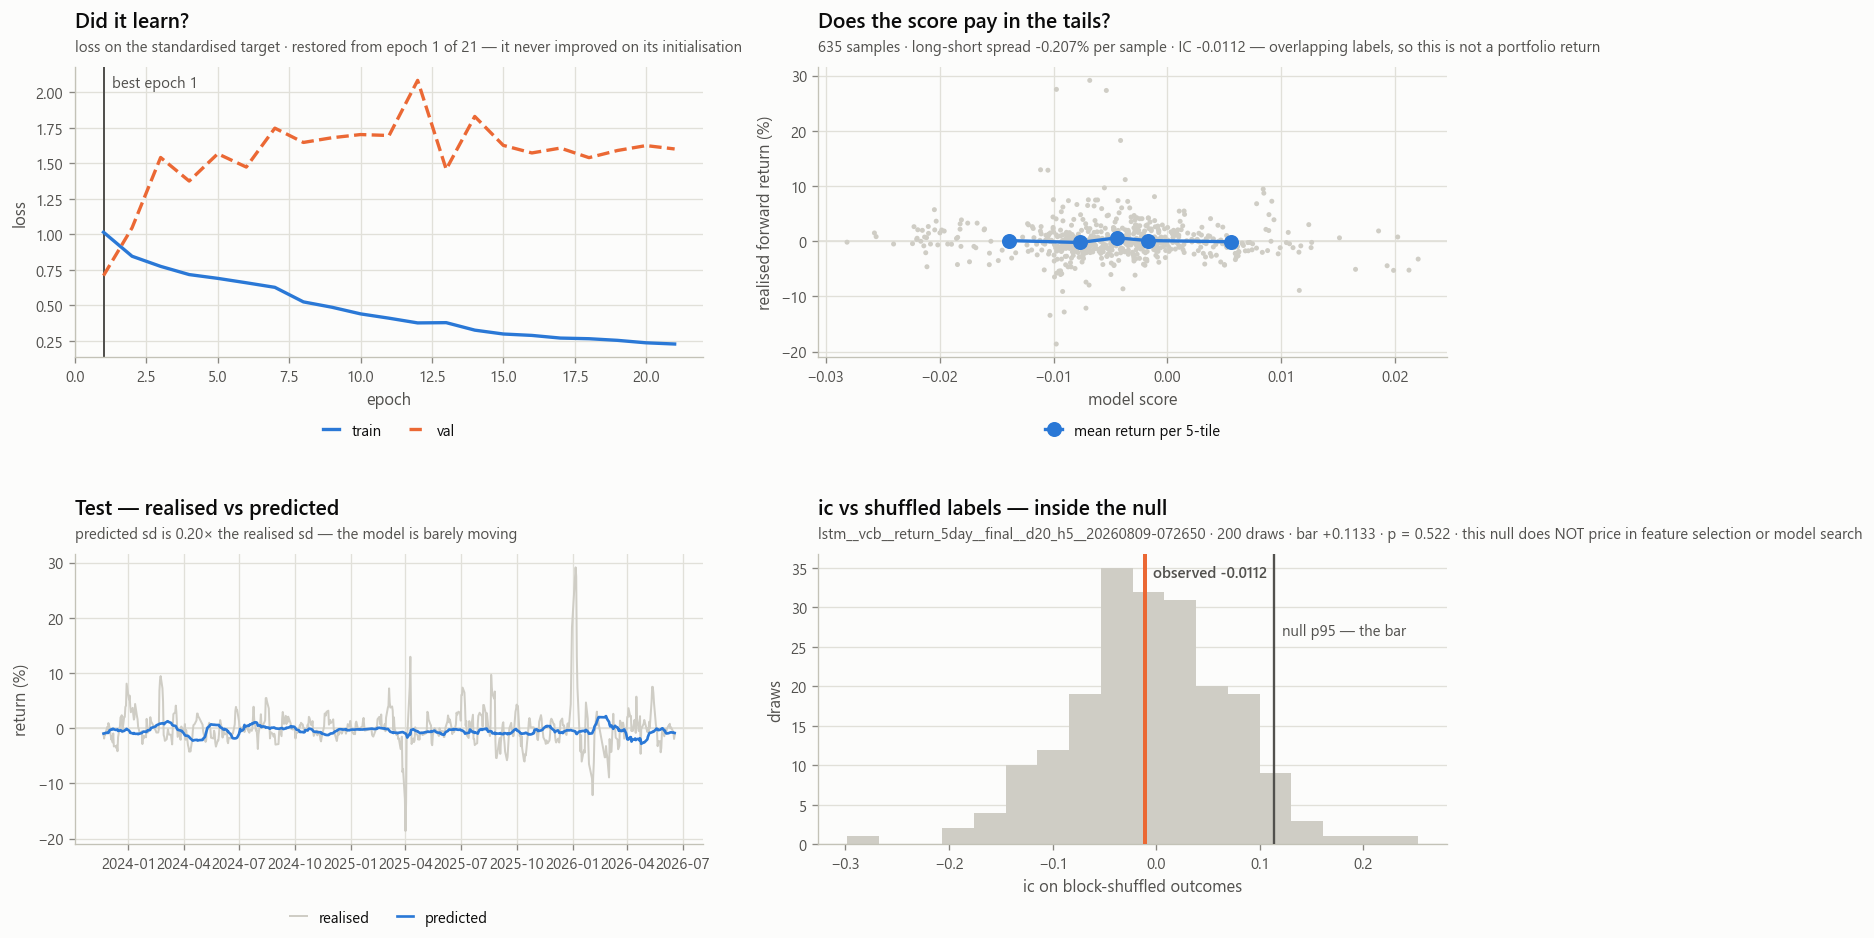

In [8]:
figure = run_figures(run_dir, "test", draws=null)
plt.show()

## Every run, on one board

Sorted by `ic` — which is **not** an endorsement. `ic_clears` beside it is what
says whether the ordering means anything.

In [9]:
board = leaderboard()
columns = [
    "run_id", "model", "task", "lookback", "n_eff",
    "ic", "ic_p", "ic_clears", "dir_auc", "dir_auc_p", "dir_auc_clears",
    "long_short", "return_source",
]
board[[c for c in columns if c in board.columns]]

,run_id,model,task,lookback,n_eff,ic,ic_p,ic_clears,dir_auc,dir_auc_p,dir_auc_clears,long_short,return_source
0,lstm__probability_gain_5pct_5day__lb15__final_...,LSTM,classification,15,127.2,0.137921,0.009950,True,0.655274,0.009950,True,0.094488,label (no dataset reference)
1,lstm__probability_gain_5pct_5day__lb25__final_...,LSTM,classification,25,127.2,0.126799,0.024876,True,0.642752,0.024876,True,0.070866,label (no dataset reference)
2,lstm__probability_gain_5pct_5day__lb1__final__...,LSTM,classification,1,127.2,0.125230,0.024876,True,0.640985,0.024876,True,0.110236,label (no dataset reference)
3,lstm__return_5day__lb2__final__20260704-082822,LSTM,regression,2,127.2,0.119472,0.029851,True,0.559486,0.044776,True,0.008679,y_true
4,lstm__return_5day__lb1__final__20260704-082835,LSTM,regression,1,127.2,0.113833,0.044776,True,0.550828,0.089552,False,0.010226,y_true
5,lstm__direction_5day__lb5__final__20260704-214356,LSTM,classification,5,127.2,0.083468,0.099502,False,0.548596,0.099502,False,0.110236,label (no dataset reference)
6,lstm__direction_5day__lb25__final__20260704-21...,LSTM,classification,25,127.2,0.068096,0.089552,False,0.539646,0.089552,False,0.078740,label (no dataset reference)
7,lstm__direction_5day__lb3__final__20260704-214351,LSTM,classification,3,127.2,0.047749,0.179104,False,0.527800,0.179104,False,0.062992,label (no dataset reference)
8,lstm__direction_5day__lb15__final__20260704-21...,LSTM,classification,15,127.2,0.045089,0.243781,False,0.526251,0.243781,False,-0.062992,label (no dataset reference)
9,lstm__direction_5day__lb1__final__20260704-214339,LSTM,classification,1,127.2,0.040253,0.203980,False,0.523436,0.203980,False,0.023622,label (no dataset reference)


## ⚠️ What a cleared bar does and does not mean

The null here shuffles the **outcome** against a fixed score vector. By the time
it runs, the features were selected, the architecture was chosen and the epoch
was early-stopped on val — none of which it prices in. Unlike
`feature_selection.evaluation.null_distribution`, it cannot re-run the selection.

**A run that fails this bar is dead. A run that clears it is not yet alive.**

And the features themselves carry a warning one stage further up: all 19
feature-selection runs behind this table computed no null at all
(`feature_selection/CONTEXT.md` §14b), and 199 of the 203 channels were chosen by
exactly one run (`final_features/CONTEXT.md` §6).